# Fruit Recognition Using a Convolutional Neural Network

This project investigates image classification using a Convolutional Neural Network (CNN). The goal is to classify images of fruits into one of nine fruit categories.

The project uses the Fruits Dataset Images dataset from Kaggle and uses ResNet50 with transfer learning to train the image classification model.

In [27]:
import os
import random
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import tensorflow as tf
from tensorflow.keras.applications import ResNet50

In [28]:
dataset_path = Path("/workspaces/CSCI441/ResearchAssignment/fruits-dataset/images")

classes = sorted([
    folder.name
    for folder in dataset_path.iterdir()
    if folder.is_dir()
])

print("Fruit classes:")
for fruit in classes:
    print(f"- {fruit}")

print(f"\nNumber of classes: {len(classes)}")

Fruit classes:
- apple fruit
- banana fruit
- cherry fruit
- chickoo fruit
- grapes fruit
- kiwi fruit
- mango fruit
- orange fruit
- strawberry fruit

Number of classes: 9


In [29]:
total_images = 0

image_extensions = [".jpg", ".jpeg", ".png", ".gif"]

for fruit in classes:
    fruit_path = dataset_path / fruit
    
    image_files = [
        file for file in fruit_path.iterdir()
        if file.suffix.lower() in image_extensions
    ]
    
    print(f"{fruit}: {len(image_files)} images")
    total_images += len(image_files)

print(f"\nTotal images: {total_images}")

apple fruit: 40 images
banana fruit: 40 images
cherry fruit: 40 images
chickoo fruit: 40 images
grapes fruit: 40 images
kiwi fruit: 40 images
mango fruit: 40 images
orange fruit: 40 images
strawberry fruit: 40 images

Total images: 360


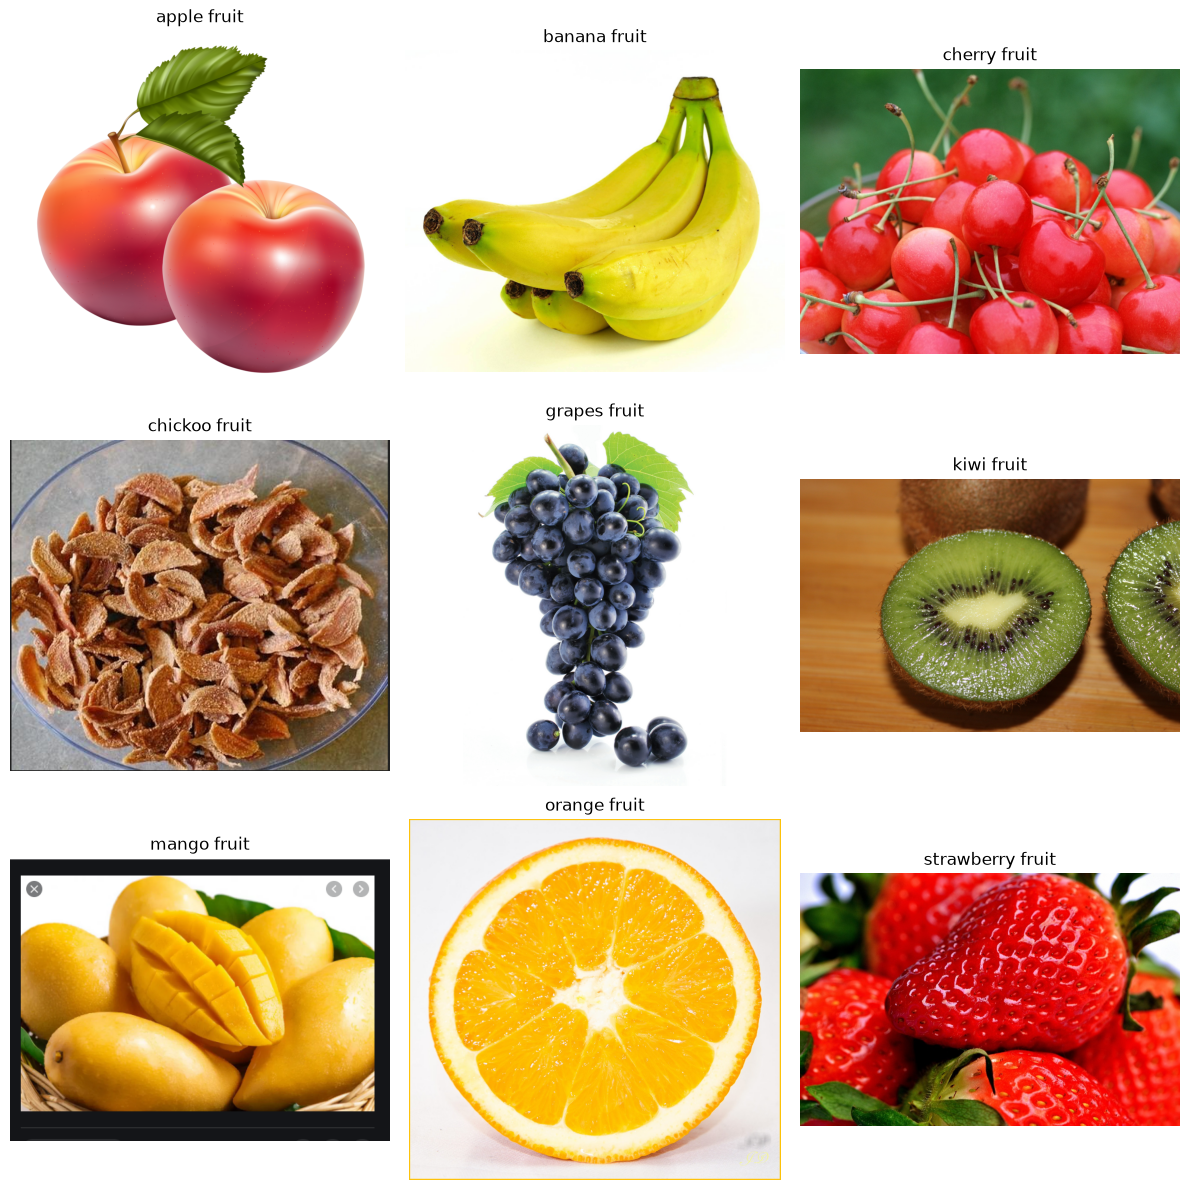

In [30]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, fruit in zip(axes.ravel(), classes):
    fruit_path = dataset_path / fruit
    
    image_files = [
        file for file in fruit_path.iterdir()
        if file.suffix.lower() in image_extensions
    ]
    
    image = Image.open(image_files[0])
    
    ax.imshow(image)
    ax.set_title(fruit)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [31]:
dimensions = []

for fruit in classes:
    fruit_path = dataset_path / fruit
    
    for file in fruit_path.iterdir():
        if file.suffix.lower() in image_extensions:
            with Image.open(file) as image:
                dimensions.append(image.size)

dimension_counts = Counter(dimensions)

print(f"Total images: {len(dimensions)}")
print(f"Number of unique dimensions: {len(dimension_counts)}")

print("\nMost common image dimensions:")
for dimension, count in dimension_counts.most_common(10):
    print(f"{dimension}: {count} images")

Total images: 360
Number of unique dimensions: 268

Most common image dimensions:
(1600, 1200): 15 images
(1024, 768): 14 images
(1920, 1200): 8 images
(600, 600): 6 images
(2560, 1600): 6 images
(1920, 1080): 5 images
(800, 600): 5 images
(1200, 900): 4 images
(500, 500): 4 images
(1280, 720): 4 images


In [32]:
random.seed(42)

train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

train_data = []
val_data = []
test_data = []

for fruit in classes:
    fruit_path = dataset_path / fruit
    
    image_files = [
        file for file in fruit_path.iterdir()
        if file.suffix.lower() in image_extensions
    ]
    
    random.shuffle(image_files)
    
    train_end = int(len(image_files) * train_ratio)
    val_end = train_end + int(len(image_files) * val_ratio)
    
    train_files = image_files[:train_end]
    val_files = image_files[train_end:val_end]
    test_files = image_files[val_end:]
    
    train_data.extend([(file, fruit) for file in train_files])
    val_data.extend([(file, fruit) for file in val_files])
    test_data.extend([(file, fruit) for file in test_files])

print(f"Training images: {len(train_data)}")
print(f"Validation images: {len(val_data)}")
print(f"Testing images: {len(test_data)}")
print(f"Total: {len(train_data) + len(val_data) + len(test_data)}")

Training images: 252
Validation images: 54
Testing images: 54
Total: 360


In [33]:
print("Training:")
print(Counter(label for _, label in train_data))

print("\nValidation:")
print(Counter(label for _, label in val_data))

print("\nTesting:")
print(Counter(label for _, label in test_data))

Training:
Counter({'apple fruit': 28, 'banana fruit': 28, 'cherry fruit': 28, 'chickoo fruit': 28, 'grapes fruit': 28, 'kiwi fruit': 28, 'mango fruit': 28, 'orange fruit': 28, 'strawberry fruit': 28})

Validation:
Counter({'apple fruit': 6, 'banana fruit': 6, 'cherry fruit': 6, 'chickoo fruit': 6, 'grapes fruit': 6, 'kiwi fruit': 6, 'mango fruit': 6, 'orange fruit': 6, 'strawberry fruit': 6})

Testing:
Counter({'apple fruit': 6, 'banana fruit': 6, 'cherry fruit': 6, 'chickoo fruit': 6, 'grapes fruit': 6, 'kiwi fruit': 6, 'mango fruit': 6, 'orange fruit': 6, 'strawberry fruit': 6})


In [34]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50

print("TensorFlow version:", tf.__version__)
print("ResNet50 imported successfully!")

TensorFlow version: 2.21.0
ResNet50 imported successfully!


In [35]:
image_path, label = train_data[0]

image = Image.open(image_path).convert("RGB")

print("Original size:", image.size)
print("Label:", label)

image_resized = image.resize((224, 224))

print("Resized size:", image_resized.size)

Original size: (2265, 1500)
Label: apple fruit
Resized size: (224, 224)


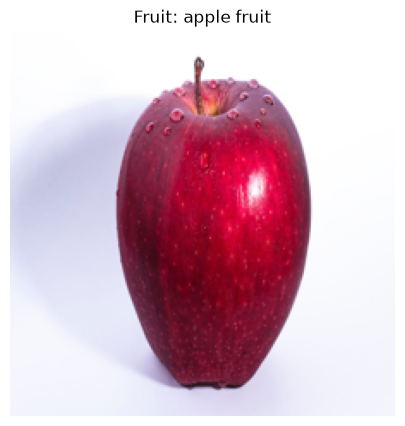

In [36]:
plt.figure(figsize=(5, 5))
plt.imshow(image_resized)
plt.title(f"Fruit: {label}")
plt.axis("off")
plt.show()

In [11]:
# Assign a number to each fruit class

label_to_index = {fruit: i for i, fruit in enumerate(classes)}

print(label_to_index)

{'apple fruit': 0, 'banana fruit': 1, 'cherry fruit': 2, 'chickoo fruit': 3, 'grapes fruit': 4, 'kiwi fruit': 5, 'mango fruit': 6, 'orange fruit': 7, 'strawberry fruit': 8}


In [13]:
import random
import numpy as np
from pathlib import Path
from PIL import Image

# -----------------------------------------
# 1. Dataset setup
# -----------------------------------------

dataset_path = Path(
    "/workspaces/CSCI441/ResearchAssignment/fruits-dataset/images"
)

classes = sorted([
    folder.name
    for folder in dataset_path.iterdir()
    if folder.is_dir()
])

print("Classes:")
for fruit in classes:
    print("-", fruit)

print("\nNumber of classes:", len(classes))


# -----------------------------------------
# 2. Create label mapping
# -----------------------------------------

label_to_index = {
    fruit: i for i, fruit in enumerate(classes)
}

index_to_label = {
    i: fruit for fruit, i in label_to_index.items()
}


# -----------------------------------------
# 3. Recreate the same train/validation/test split
# -----------------------------------------

random.seed(42)

train_ratio = 0.70
val_ratio = 0.15

train_data = []
val_data = []
test_data = []

image_extensions = [
    ".jpg",
    ".jpeg",
    ".png",
    ".gif"
]

for fruit in classes:

    fruit_path = dataset_path / fruit

    image_files = [
        file
        for file in fruit_path.iterdir()
        if file.suffix.lower() in image_extensions
    ]

    # Same shuffle seed as before
    random.shuffle(image_files)

    train_end = int(len(image_files) * train_ratio)
    val_end = train_end + int(len(image_files) * val_ratio)

    train_files = image_files[:train_end]
    val_files = image_files[train_end:val_end]
    test_files = image_files[val_end:]

    train_data.extend(
        [(file, fruit) for file in train_files]
    )

    val_data.extend(
        [(file, fruit) for file in val_files]
    )

    test_data.extend(
        [(file, fruit) for file in test_files]
    )


print("\nDataset split:")
print("Training:", len(train_data))
print("Validation:", len(val_data))
print("Testing:", len(test_data))


# -----------------------------------------
# 4. Load and resize images
# -----------------------------------------

def load_images(data):

    images = []
    labels = []

    for image_path, label in data:

        image = Image.open(
            image_path
        ).convert("RGB")

        image = image.resize(
            (224, 224)
        )

        images.append(
            np.array(
                image,
                dtype=np.float32
            )
        )

        labels.append(
            label_to_index[label]
        )

    return (
        np.array(images),
        np.array(labels)
    )


# Load all three datasets
X_train, y_train = load_images(train_data)
X_val, y_val = load_images(val_data)
X_test, y_test = load_images(test_data)


print("\nArray shapes:")
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)

Classes:
- apple fruit
- banana fruit
- cherry fruit
- chickoo fruit
- grapes fruit
- kiwi fruit
- mango fruit
- orange fruit
- strawberry fruit

Number of classes: 9

Dataset split:
Training: 252
Validation: 54
Testing: 54

Array shapes:
Training: (252, 224, 224, 3) (252,)
Validation: (54, 224, 224, 3) (54,)
Testing: (54, 224, 224, 3) (54,)


In [15]:
from tensorflow.keras.applications.resnet50 import preprocess_input

X_train = preprocess_input(X_train)
X_val = preprocess_input(X_val)
X_test = preprocess_input(X_test)

print("ResNet50 preprocessing applied!")

ResNet50 preprocessing applied!


In [16]:
from tensorflow.keras.applications import ResNet50

# Load ResNet50 pretrained on ImageNet
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained layers
base_model.trainable = False

print("ResNet50 loaded successfully!")
print("Number of layers:", len(base_model.layers))

ResNet50 loaded successfully!
Number of layers: 175


In [18]:
from tensorflow.keras import layers, models

# Create the model
model = models.Sequential([
    base_model,
    
    # Convert ResNet50 feature maps into a single feature vector
    layers.GlobalAveragePooling2D(),
    
    # Helps reduce overfitting
    layers.Dropout(0.3),
    
    # 9 output classes for our 9 fruits
    layers.Dense(9, activation="softmax")
])

# Show the model structure
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │        18,441 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,606,153 (90.05 MB)

 Trainable params: 18,441 (72.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [20]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [21]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=16,
    callbacks=[early_stopping]
)

Epoch 1/15


W0000 00:00:1789601004.755586    3723 cpu_allocator_impl.cc:82] Allocation of 151732224 exceeds 10% of free system memory.
W0000 00:00:1789601010.853472   16839 cpu_allocator_impl.cc:82] Allocation of 51380224 exceeds 10% of free system memory.
W0000 00:00:1789601010.978080   16839 cpu_allocator_impl.cc:82] Allocation of 53231616 exceeds 10% of free system memory.
W0000 00:00:1789601011.023570   16840 cpu_allocator_impl.cc:82] Allocation of 51380224 exceeds 10% of free system memory.
W0000 00:00:1789601011.120504   16839 cpu_allocator_impl.cc:82] Allocation of 51380224 exceeds 10% of free system memory.


16/16 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.3929 - loss: 1.8078 - val_accuracy: 0.7593 - val_loss: 0.8055
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.8175 - loss: 0.6229 - val_accuracy: 0.8704 - val_loss: 0.3918
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9167 - loss: 0.2892 - val_accuracy: 0.9259 - val_loss: 0.2871
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9643 - loss: 0.1958 - val_accuracy: 0.9444 - val_loss: 0.2333
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.9722 - loss: 0.1393 - val_accuracy: 0.9444 - val_loss: 0.1888
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.9881 - loss: 0.1059 - val_accuracy: 0.9259 - val_loss: 0.1795
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.9921 - loss: 0.0871 - val_accuracy: 0.9259 - val_loss: 0.1590
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9960 - loss: 0.0744 - val_accuracy: 0.9444 - val_loss: 0.1425
Epo

In [22]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

Test loss: 0.3911
Test accuracy: 0.8704
Test accuracy: 87.04%


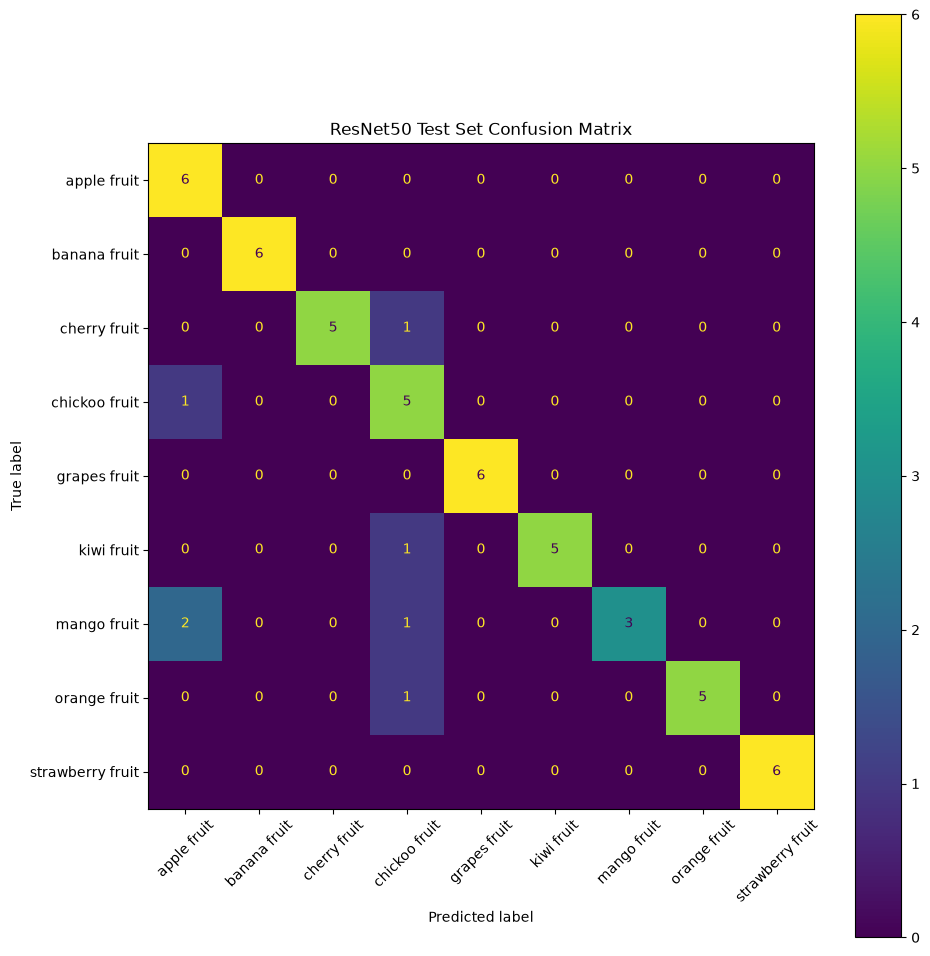

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions for the test set
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)

plt.title("ResNet50 Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

In [24]:
model.save(
    "/workspaces/CSCI441/ResearchAssignment/fruit_resnet50.keras"
)

print("Model saved successfully!")

Model saved successfully!


In [25]:
from pathlib import Path
from PIL import Image
import numpy as np
from tensorflow.keras.applications.resnet50 import preprocess_input

unseen_path = Path(
    "/workspaces/CSCI441/ResearchAssignment/unseen_images"
)

unseen_files = sorted([
    file for file in unseen_path.iterdir()
    if file.suffix.lower() in [".jpg", ".jpeg", ".png", ".gif"]
])

correct = 0
total = len(unseen_files)

print("Unseen image predictions:\n")

for image_path in unseen_files:

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Resize to ResNet50 input size
    image = image.resize((224, 224))

    # Convert to NumPy array
    image_array = np.array(image, dtype=np.float32)

    # Add batch dimension
    image_array = np.expand_dims(image_array, axis=0)

    # Apply ResNet50 preprocessing
    image_array = preprocess_input(image_array)

    # Predict
    prediction = model.predict(image_array, verbose=0)

    predicted_index = np.argmax(prediction[0])
    predicted_class = index_to_label[predicted_index]
    confidence = prediction[0][predicted_index] * 100

    # Expected class comes from filename
    expected_class = image_path.stem

    # Convert filename to dataset class name
    expected_class = expected_class + " fruit"

    is_correct = predicted_class == expected_class

    if is_correct:
        correct += 1

    result = "✓ Correct" if is_correct else "✗ Incorrect"

    print(
        f"{image_path.name}: "
        f"Predicted = {predicted_class} "
        f"({confidence:.2f}%) | "
        f"Expected = {expected_class} | "
        f"{result}"
    )

print(f"\nUnseen image accuracy: {correct}/{total}")
print(f"Unseen image accuracy: {correct / total * 100:.2f}%")

Unseen image predictions:

apple.jpg: Predicted = mango fruit (68.41%) | Expected = apple fruit | ✗ Incorrect
banana.jpg: Predicted = banana fruit (67.14%) | Expected = banana fruit | ✓ Correct
cherry.jpg: Predicted = strawberry fruit (87.07%) | Expected = cherry fruit | ✗ Incorrect
chickoo.jpg: Predicted = chickoo fruit (99.45%) | Expected = chickoo fruit | ✓ Correct
grapes.jpg: Predicted = chickoo fruit (66.94%) | Expected = grapes fruit | ✗ Incorrect
kiwi.jpg: Predicted = kiwi fruit (99.28%) | Expected = kiwi fruit | ✓ Correct
mango.jpg: Predicted = mango fruit (84.67%) | Expected = mango fruit | ✓ Correct
orange.jpg: Predicted = mango fruit (82.50%) | Expected = orange fruit | ✗ Incorrect
strawberry.jpg: Predicted = strawberry fruit (96.06%) | Expected = strawberry fruit | ✓ Correct

Unseen image accuracy: 5/9
Unseen image accuracy: 55.56%


In [2]:
from tensorflow.keras.models import load_model

model = load_model(
    "/workspaces/CSCI441/ResearchAssignment/fruit_resnet50.keras"
)

print("Model loaded successfully!")

E0000 00:00:1789602437.198664   32923 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model loaded successfully!


In [4]:
classes = [
    "apple fruit",
    "banana fruit",
    "cherry fruit",
    "chickoo fruit",
    "grapes fruit",
    "kiwi fruit",
    "mango fruit",
    "orange fruit",
    "strawberry fruit"
]

index_to_label = {
    i: fruit for i, fruit in enumerate(classes)
}

print(index_to_label)

{0: 'apple fruit', 1: 'banana fruit', 2: 'cherry fruit', 3: 'chickoo fruit', 4: 'grapes fruit', 5: 'kiwi fruit', 6: 'mango fruit', 7: 'orange fruit', 8: 'strawberry fruit'}


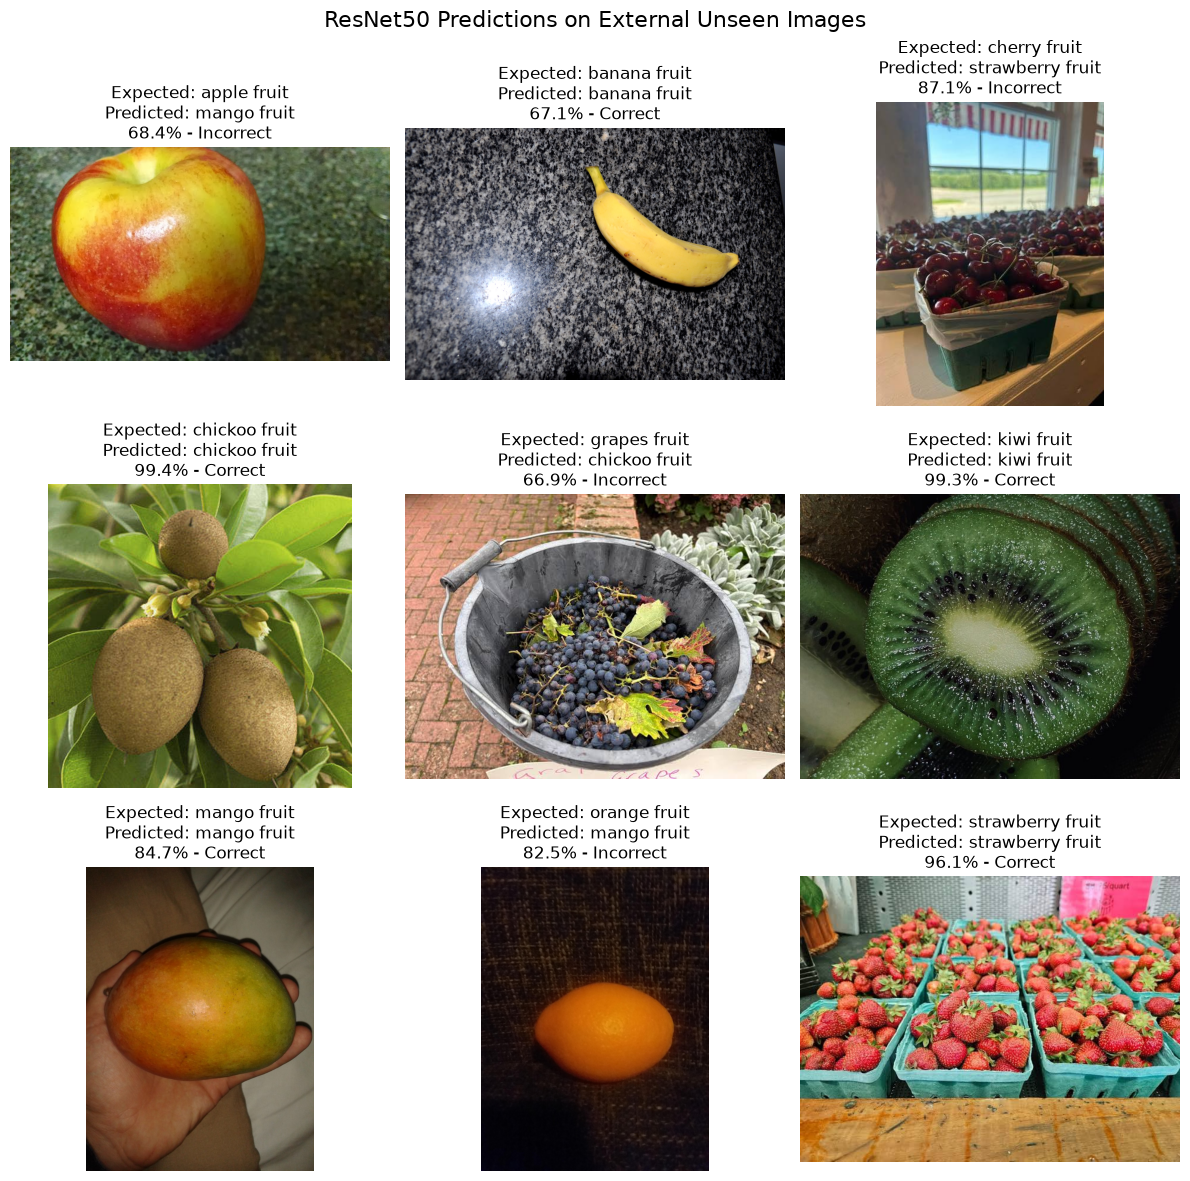

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import numpy as np
from tensorflow.keras.applications.resnet50 import preprocess_input

unseen_path = Path(
    "/workspaces/CSCI441/ResearchAssignment/unseen_images"
)

unseen_files = sorted([
    file for file in unseen_path.iterdir()
    if file.suffix.lower() in [".jpg", ".jpeg", ".png", ".gif"]
])

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, image_path in zip(axes.ravel(), unseen_files):

    display_image = Image.open(image_path).convert("RGB")

    image = display_image.resize((224, 224))
    image_array = np.array(image, dtype=np.float32)
    image_array = np.expand_dims(image_array, axis=0)
    image_array = preprocess_input(image_array)

    prediction = model.predict(image_array, verbose=0)

    predicted_index = np.argmax(prediction[0])
    predicted_class = index_to_label[predicted_index]
    confidence = prediction[0][predicted_index] * 100

    expected_class = image_path.stem + " fruit"

    if predicted_class == expected_class:
        result = "Correct"
    else:
        result = "Incorrect"

    ax.imshow(display_image)

    ax.set_title(
        f"Expected: {expected_class}\n"
        f"Predicted: {predicted_class}\n"
        f"{confidence:.1f}% - {result}"
    )

    ax.axis("off")

plt.suptitle(
    "ResNet50 Predictions on External Unseen Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [6]:
results = [
    ["Training", "252", "100.00%"],
    ["Validation", "54", "96.30%"],
    ["Test", "54", "87.04%"],
    ["External Unseen", "9", "55.56%"]
]

print("ResNet50 Results")
print("-" * 40)

for dataset, images, accuracy in results:
    print(f"{dataset:<20} {images:<8} {accuracy}")

ResNet50 Results
----------------------------------------
Training             252      100.00%
Validation           54       96.30%
Test                 54       87.04%
External Unseen      9        55.56%
